# Práctica 1 — MODELO DE PÉRDIDAS DE CRÉDITO
Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Facultad de Ciencias, UNAM
Marcial, Samari, Dani, Valeria, Ximena y yo

## a) Exploración de las variables de interés

In [59]:
#Librerías que vamos a necesitar.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import numpy as np
from statsmodels.discrete.discrete_model import Poisson, NegativeBinomial
from statsmodels.discrete.count_model import ZeroInflatedPoisson
import statsmodels.api as sm


In [47]:
# Configuración de estilo visual
sns.set_theme(style="whitegrid")

# 1. Definimos la ruta del archivo .parquet específico del ramo de crédito.
# Reemplaza 'equipo_XX' con tu número de equipo correspondiente
ruta_archivo = "../inputs/cartera.parquet"

# 2. Cargar el archivo .parquet
df = pd.read_parquet(ruta_archivo)

# 3. Inspección inicial de las columnas disponibles
print("¡Archivo cargado con éxito!")
print(f"Total de registros: {df.shape[0]} | Total de columnas: {df.shape[1]}\n")
print("Nombres de las columnas en el dataset:")
print(df.columns.tolist())

¡Archivo cargado con éxito!
Total de registros: 30000 | Total de columnas: 13

Nombres de las columnas en el dataset:
['id_poliza', 'exposicion', 'monto_credito', 'plazo_meses', 'calificacion_deudor', 'sector', 'tipo_credito', 'suma_asegurada', 'deducible', 'coaseguro', 'num_siniestros', 'monto_total_siniestros', 'monto_promedio_siniestro']


--- TABLA DESCRIPTIVA DE VARIABLES DE INTERÉS ---


,Conteo,Media,Desv. Est.,Mínimo,Mediana,Máximo,Sesgo (Skewness)
num_siniestros,30000.0,0.037933,2.018971e-01,0.000,0.000,3.000,5.716393
exposicion,30000.0,0.800478,1.201295e-01,0.198,0.821,0.999,-0.821936
monto_total_siniestros,30000.0,7896.310809,1.020352e+05,0.000,0.000,8373783.910,35.765535
monto_promedio_siniestro,1079.0,206892.565904,4.723936e+05,1830.430,73075.520,8373783.910,8.144362
deducible,30000.0,28109.928467,2.270885e+04,1185.000,21958.000,412009.000,3.047860
coaseguro,30000.0,0.100000,1.387802e-17,0.100,0.100,0.100,0.000000


C:\Users\ortiz\AppData\Local\Temp\ipykernel_23528\1298469738.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='num_siniestros', ax=axes[0], palette='Blues_d')


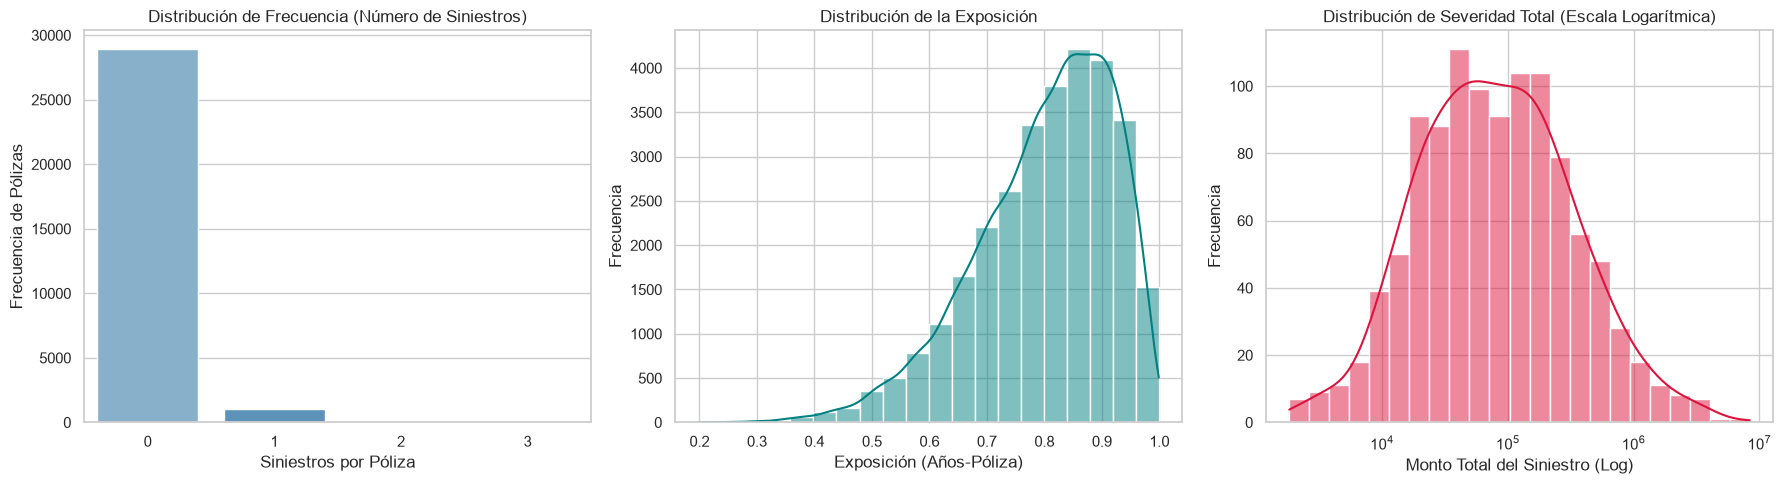

In [48]:
# 1. SELECCIÓN Y JUSTIFICACIÓN DE VARIABLES
# Para el análisis agregado elegimos solo las variables de frecuencia, exposición y severidad:
cols_interes = ['num_siniestros', 'exposicion', 'monto_total_siniestros', 'monto_promedio_siniestro', 'deducible', 'coaseguro']

# 2. ESTADÍSTICOS DESCRIPTIVOS BÁSICOS
# Generamos la tabla descriptiva básica
descriptivos = df[cols_interes].describe().T
descriptivos['mediana'] = df[cols_interes].median()
descriptivos['sesgo_skew'] = df[cols_interes].skew()

# Reordenamos columnas para presentarlo de forma ejecutiva
resumen = descriptivos[['count', 'mean', 'std', 'min', 'mediana', 'max', 'sesgo_skew']]
resumen.columns = ['Conteo', 'Media', 'Desv. Est.', 'Mínimo', 'Mediana', 'Máximo', 'Sesgo (Skewness)']

print("--- TABLA DESCRIPTIVA DE VARIABLES DE INTERÉS ---")
display(resumen)

# 3. VISUALIZACIÓN DE LAS DISTRIBUCIONES
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A) Frecuencia (Número de Siniestros)
sns.countplot(data=df, x='num_siniestros', ax=axes[0], palette='Blues_d')
axes[0].set_title("Distribución de Frecuencia (Número de Siniestros)")
axes[0].set_xlabel("Siniestros por Póliza")
axes[0].set_ylabel("Frecuencia de Pólizas")

# B) Exposición (Años-Póliza)
sns.histplot(df['exposicion'], kde=True, ax=axes[1], color='teal', bins=20)
axes[1].set_title("Distribución de la Exposición")
axes[1].set_xlabel("Exposición (Años-Póliza)")
axes[1].set_ylabel("Frecuencia")

# C) Severidad (Montos en escala logarítmica para manejar la cola pesada)
# Filtramos solo pólizas con siniestralidad mayor a 0
df_siniestrados = df[df['monto_total_siniestros'] > 0]
sns.histplot(df_siniestrados['monto_total_siniestros'], log_scale=True, kde=True, ax=axes[2], color='crimson')
axes[2].set_title("Distribución de Severidad Total (Escala Logarítmica)")
axes[2].set_xlabel("Monto Total del Siniestro (Log)")
axes[2].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

El indicador "% de pólizas con siniesztro" con 3.6 % y la primera grafica nos ayudan a demostrar que las reclamaciones son eventos poco comunes. 

La masa de datos se concentra casi por completo en cero siniestros. El riesgo de la cartera se encuentrá en la severidad del evento cuando el evento ocurre y no en la frecuencia diaria.

### Selección y Justificación de Variables.

En esta práctica calculamos la prima pura de forma agregada, por lo que usamos una sola distribución de frecuencia y severidad para toda la cartera. 

Por ello, solo seleccionamos las variables necesarias para modelar la pérdida agregada $S$ y dejamos fuera la segmentación individual.

- Variables que sí utilizamos:

    - num_siniestros (Frecuencia, $N$): Cantidad de siniestros por póliza. Es la variable clave para ajustar la distribución discreta de frecuencia.

    - exposicion: Tiempo en años-póliza que la cobertura estuvo activa. Nos sirve para estandarizar la frecuencia según el tiempo expuesto.

    - monto_total_siniestros / monto_promedio_siniestro (Severidad, $Y$): Pérdida real (ground-up) sufrida en cada evento. Con esta variable ajustamos la distribución continua de severidad.

    - deducible y coaseguro: Condiciones de la póliza necesarias para calcular la severidad real que termina pagando la aseguradora ($Y_{\text{pagada}}$).

- Variables excluidas:

    - Factores de riesgo (monto_credito, sector, calificacion_deudor, etc.): 

Se omiten por ahora porque sirven para diferenciar el riesgo por tipo de cliente. Esas covariables las utilizaremos hasta la Práctica 2 al implementar los modelos GLM.

## b) Severidad
- Ajusten varias distribuciones (lognormal, gamma, Weibull, Pareto…) y elijan una con criterio : AIC y el comportamiento de la cola (no solo el número).

In [49]:
#Tomando en cuenta que severidad  : monto_promedio_siniestro (ground-up)
#Calculamos el valor segun nuestros datos: 
df_siniestros = df[df['num_siniestros'] > 0].copy()

media_sev = df_siniestros['monto_promedio_siniestro'].mean()
mediana_sev = df_siniestros['monto_promedio_siniestro'].median()
print(f"Severidad → media {media_sev:,.0f} mediana {mediana_sev:,.0f}")

# Avancemos viendo como se ven nuestros datos de severidad reales
# Nuestra variable de interés (Severidad)
sev = df_siniestros['monto_promedio_siniestro'].dropna()
print("\nEstadísticas descriptivas de la severidad:")
print(sev.describe().round(1).to_string())
print(f"Sesgo (Skewness): {skew(sev):.2f}")

Severidad → media 206,893 mediana 73,076

Estadísticas descriptivas de la severidad:
count       1079.0
mean      206892.6
std       472393.6
min         1830.4
25%        28234.8
50%        73075.5
75%       196564.9
max      8373783.9
Sesgo (Skewness): 8.13


El Sesgo de 8.13 es demasiado alto hacia la derecha, lo que significa que la cola de la distribución es muy pesada en el lado derecho. 

Esto indica claramente que la distribución no es simétrica. Por lo que, las distribuciones simetricas, especialmente la Normal, no pueden aplicarse.

Para ver la asimetria de los datos, graficaremos la severidad en su escala natural y aplicaremos una transformación logarítmica. 

Esta última es una tecnica habitual en el sector de seguros, pues nos ayuda a que la varianza sea más estable.

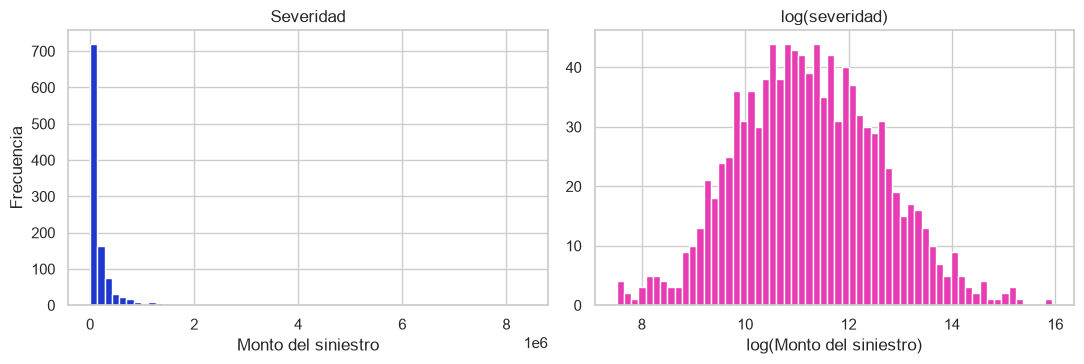

Sesgo=8.13   Media=206,893   Mediana=73,076


In [50]:
# ─── La forma: escala natural vs. log ──────────────────────────────────────
# En escala natural
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(sev, bins=60, color="#1E38CE", edgecolor="white"); ax[0].set_title("Severidad")
ax[0].set_xlabel("Monto del siniestro"); ax[0].set_ylabel("Frecuencia")

# En escala logarítmica (ayuda a ver colas pesadas)
# Filtramos sev > 0 por si hay algún error con montos en cero al sacar el logaritmo
sev_positiva = sev[sev > 0]
ax[1].hist(np.log(sev), bins=60, color="#E83CB4", edgecolor="white"); ax[1].set_title("log(severidad)")
ax[1].set_xlabel("log(Monto del siniestro)")

plt.tight_layout(); plt.show()
print(f"Sesgo={skew(sev):.2f}   Media={sev.mean():,.0f}   Mediana={np.median(sev):,.0f}")

Notece que la Media es casi el triple de la Mediana, esto sumado al valor calculado de Maximo Extremo (de 8,373,784), nos dice que la cartera sufre de siniestros catastroficos o de alta severidad que llevarán el promedio hacia arriba.

El 50% de los siniestros cuestan menos de 73 mil, pero los eventos extremos distorsionan el promedio general.

Antes de proponer modelos, es importante conocer como actua la cartera en la realidad. En este bloque, filtraremos solo las pólizas que tengan reclamaciones (num_siniestros > 0) para centrar el análisis en la severidad. 

Se calculara la tasa de incidencia en relación con la exposición total (años-póliza). También se compararán las medidas de tendencia central de los montos para ver si hay señales de asimetría en los datos.


% de pólizas con siniestro : 3.6%
Exposición total           : 24,014 años-póliza
Severidad (monto_promedio) → media 206,893  mediana 73,076


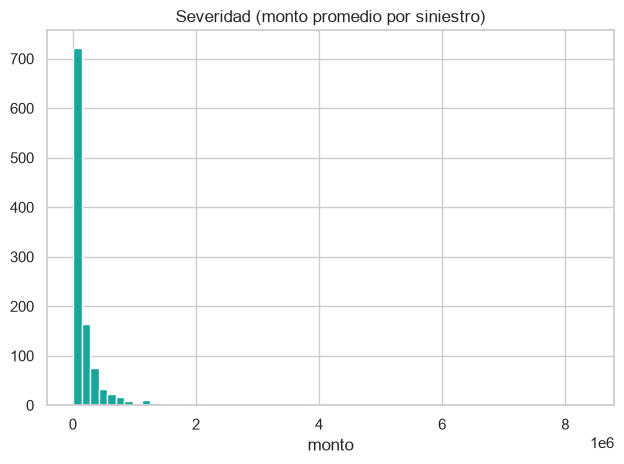

In [51]:
# ─── Exploración enfocada ──────────────────────────────────────────────────
con = df[df.num_siniestros > 0]         # pólizas con al menos un siniestro
print(f"% de pólizas con siniestro : {(df.num_siniestros>0).mean():.1%}")
print(f"Exposición total           : {df.exposicion.sum():,.0f} años-póliza")
print(f"Severidad (monto_promedio) → media {con.monto_promedio_siniestro.mean():,.0f}  "
      f"mediana {con.monto_promedio_siniestro.median():,.0f}")


plt.hist(con.monto_promedio_siniestro, bins=60, color="#17A69B", edgecolor="white")
plt.title("Severidad (monto promedio por siniestro)"); plt.xlabel("monto")
plt.tight_layout(); plt.show()

Basandonos en la asimetría que encontramos, vamos a ajustar distribuciones candidatas para colas pesadas. 

Consideraremos Lognormal, Weibull, Gamma y Pareto. Despues evaluaremos cada una de ellas para ver qué tan bien se ajustan a los datos. 

Usaremos el criterio AIC como herramienta para medir la bondad de ajuste.

In [52]:
# Ahora ajustaremos los datos y calcularemos el AIC como lo vimos en clase :)
def aic(dist, params, datos):
    return 2 * len(params) - 2 * np.sum(dist.logpdf(datos, *params))

candidatas = {"Lognormal": stats.lognorm, "Gamma": stats.gamma,
              "Weibull": stats.weibull_min, "Pareto": stats.pareto}
ajustes, filas = {}, []
for nom, dist in candidatas.items():
    pr = dist.fit(sev, floc=0)
    ajustes[nom] = (dist, pr)
    filas.append({"Distribución": nom, "AIC": round(aic(dist, pr, sev), 1)})

tabla = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
mejor = tabla.iloc[0]["Distribución"]
print(tabla.to_string(index=False)); print(f"\n→ Mejor por AIC: {mejor}")

Distribución     AIC
   Lognormal 28037.1
     Weibull 28247.4
       Gamma 28375.2
      Pareto 29270.9

→ Mejor por AIC: Lognormal


Esta conclución tambien podía verse al aplicar el logaritmo (grafica log(severidad)), pues la distribución toma forma de campana casi perfecta. 

Esto representa el argumento técnico ideal para predecir y justificar que la distribución Lognormal, probablemente ofreceran los mejores valores AIC, lo cual acabamos de comprobar.

### ─── Ajuste Visual de Distribuciones Teóricas

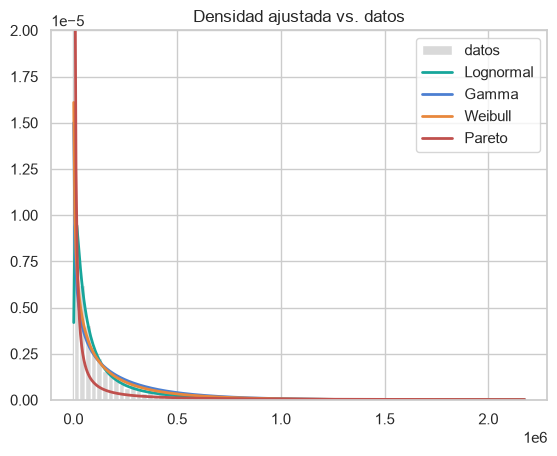

Note que la distribución Pareto explota cerca del eje "y", lo cual no se aprecia del todo 
 en la imagen porque se cortó el eje "y" para mejor apreciación de las otras distribuciones.


In [53]:
# ─── Densidad ajustada sobre el histograma ─────────────────────────────────
p99 = np.percentile(sev, 99); grid = np.linspace(sev.min(), p99, 400)
col = {"Lognormal": "#17A69B", "Gamma": "#4C7FD1", "Weibull": "#E8873C", "Pareto": "#C0504D"}
plt.hist(sev, bins=80, density=True, range=(sev.min(), p99), color="#d9d9d9", edgecolor="white", label="datos")
for nom, (d, pr) in ajustes.items():
    plt.plot(grid, d.pdf(grid, *pr), lw=2, color=col[nom], label=nom)
plt.title("Densidad ajustada vs. datos"); plt.legend(); 
#ax[0].set_ylim(0, 0.006)
plt.ylim(0, 0.00002)
plt.show()
print("Note que la distribución Pareto explota cerca del eje \"y\", lo cual no se aprecia del todo \n en la imagen porque se cortó el eje \"y\" para mejor apreciación de las otras distribuciones.")

### ─── Diagnóstico de la cola

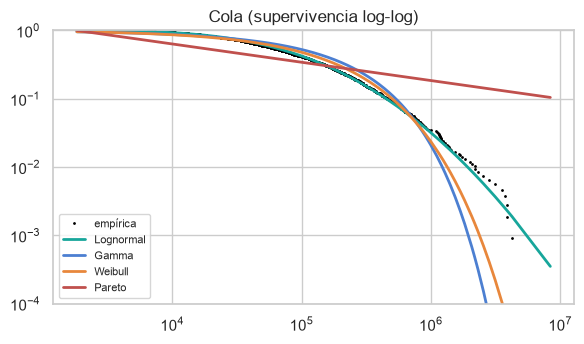

E[X] ground-up (modelo Lognormal) = 199,666


In [54]:
# ─── Diagnóstico de la cola (densidad + supervivencia) ─────────────────────
col = {"Lognormal":"#17A69B","Gamma":"#4C7FD1","Weibull":"#E8873C","Pareto":"#C0504D"}
fig, ax = plt.subplots(figsize=(6, 3.6)) 
xs = np.sort(sev)
S_emp = 1 - np.arange(1, len(xs) + 1) / len(xs)
ax.plot(xs, S_emp, ".", ms=2, color="black", label="empírica")
for nom, (d, pr) in ajustes.items():
    ax.plot(xs, d.sf(xs, *pr), color=col[nom], lw=2, label=nom)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 1)
ax.set_title("Cola (supervivencia log-log)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
    
dist_sev, pr_sev = ajustes[mejor]
print(f"E[X] ground-up (modelo {mejor}) = {dist_sev.mean(*pr_sev):,.0f}")

Observamos con este gráfico como las distribuciones no seleccionadas no son adecuadas para este caso. Por ejemplo: La Gamma y la Weibull caen después del millón, lo que en la practica actuarial significaría ignorar la posibilidad de siniestros catastroficos y cobrar primas insuficientes. Por el contrario, la Pareto es muy pesada, lo que encareceria artificialmente el producto.

El valor E[X] ground-up = 199,666 es la severidad media teórica que predice el modelo Lognormal. 
Notece que este modelo suaviza los datos reales con un valor esperado más estable (199,666), que es ligeramente diferente a la media aritmética (206,893). Esto ayuda a reducir el impacto de la volatilidad aleatoria de la muestra específica.

Este valor es clave en la tarificación, pues representa el costo promedio que se espera por cada siniestro. 

Al multiplicar esta severidad esperada (199,666) por la frecuencia esperada de siniestros, se obtiene la prima pura de riesgo necesaria para mantener la solvencia técnica de la aseguradora.

Con esto podemos concluir que la mejor distribucion es la Lognormal. Tenemos varios argumentos observados:
01. Los datos presentan asimetría derecha y una cola considerable con media 206,893 frente a mediana 73,076 y sesgo 8.13
02. La distribución Lognormal tiene el menor AIC (28,037.1), y su diferencia con de Weibull y Gamma es bastante grande.
03. Al observar la grafica, la curva de supervivencia de la Lognormal presenta un comportamiento más parecido con la cola empírica en comparación a las otras distribuciones

- Consideren las transformaciones de la póliza: distinguiendo la severidad desde cero (el daño real) de la que paga la aseguradora tras aplicar deducible etc. 

Recuerden lo de la Sesión 3: ajustar sobre datos ya transformados sesga.

### ─── Contraste entre Riesgo Bruto (Ground-Up) y Riesgo Retenido (Pagado)
Despues de revisar el comportamiento teorico de las reclamaciones, es importante medir el impacto real de las condiciones de las pólizas en la siniestralidad. 

En este apartado, compararemos las estadísticas de la severidad “Ground-Up", que es el daño total del siniestro, con la severidad “Pagada", que es el pago final de la aseguradora, sin deducibles, coaseguros o límites de suma asegurada.


In [55]:
# Nos quedamos únicamente con las pólizas que tuvieron al menos un siniestro
con = df[df["num_siniestros"] > 0].copy()

# Severidad ground-up:
# monto real promedio del siniestro antes de aplicar condiciones de póliza
X = con["monto_promedio_siniestro"].values

# Función para obtener lo que paga la aseguradora
def transformar(x, ded, coas, sa): return np.minimum( np.maximum(x - ded, 0) * (1 - coas), sa)

# Severidad transformada:
pagado = transformar(X, con["deducible"].values, con["coaseguro"].values, con["suma_asegurada"].values)

con["severidad_ground_up"] = X
con["severidad_pagada"] = pagado

print("SEVERIDAD GROUND-UP")
print(con["severidad_ground_up"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).round(2))

print("\nSEVERIDAD PAGADA")
print(con["severidad_pagada"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).round(2))

SEVERIDAD GROUND-UP
count       1079.00
mean      206892.57
std       472393.64
min         1830.43
50%        73075.52
75%       196564.94
90%       461150.23
95%       763347.12
99%      2175140.60
max      8373783.91
Name: severidad_ground_up, dtype: float64

SEVERIDAD PAGADA
count       1079.00
mean      101528.05
std       161777.56
min            0.00
50%        42169.72
75%       133446.07
90%       261144.78
95%       399041.89
99%       654173.98
max      2568872.00
Name: severidad_pagada, dtype: float64


Efectividad de los Limites de Cobertura: El siniestro maximo real (Ground-Up) alcanzo los 8.3 millones, el pago máximo de la aseguradora fue topado a 2.56 millones. La aseguradora esta efectivamente protegida contra eventos catastroficos extremos gracias a los limites de suma asegurada.


Absorcion por Deducibles: El valor mínimo de la severidad pagada baja a 0.00. Esto muestra que hubo siniestros reales (su costo mínimo fue 1,830) que no pasaron el deducible contratado. 
Por lo que el riesgo fue absorbido totalmente por el asegurado, sin crear un costo de reclamación para la compañía.

Reducción de Volatilidad: La desviación estandar (std), se reduce pasando de 472 mil a 161 mil. La cartera  pagada es mucho mas estable y predecible que el riesgo puro. 
Esto demuestra que el riesgo en la cartera pagada se ha controlado de forma efectiva, haciendo que la cartera pagada sea más segura para los inversores y para la aseguradora.

Impacto el Costo Esperado: La media aritmetica (que representa el costo esperado), cae a la mitad pasando de 206 mil a 101 mil. 
Aunque el daño promedio en la calle sea de 206 mil pesos, la aseguradora desembolsa, en promedio, solo 101,528 pesos por siniestro.

### ─── Distribución de la Perdida 

In [56]:
# Diferencia entre el daño real y lo que paga la aseguradora
con["parte_no_pagada"] = con["severidad_ground_up"] - con["severidad_pagada"]

# Porcentaje de la pérdida que no absorbe la aseguradora
con["porcentaje_no_pagado"] = (con["parte_no_pagada"] / con["severidad_ground_up"])

print("\nPROMEDIOS")
print(f"Ground-up : ${con['severidad_ground_up'].mean():,.2f}")
print(f"Pagada    : ${con['severidad_pagada'].mean():,.2f}")
print(f"No pagada : ${con['parte_no_pagada'].mean():,.2f}")

print(f"\nPorcentaje promedio no pagado: "f"{con['parte_no_pagada'].mean() / con['severidad_ground_up'].mean():.1%}")

print(f"Porcentaje promedio cubierto: "f"{con['severidad_pagada'].mean() / con['severidad_ground_up'].mean():.1%}")


PROMEDIOS
Ground-up : $206,892.57
Pagada    : $101,528.05
No pagada : $105,364.51

Porcentaje promedio no pagado: 50.9%
Porcentaje promedio cubierto: 49.1%


El costo de los siniestros se divide practicamente a la mitad. La aseguradora cubre en promedio el 49.1% del daño total (101,528), mientras que el 50.9% restante (105,364) recae directamente sobre el patrimonio del asegurado.

Efectividad Tecnica de la Póliza: Desde el punto de vista de la solvencia acturial, el diseño del producto es muy restrictivo y protege mucho a la compañía. Los contratos logran reducir la severidad media en más de 100 mil pesos por evento, demostrando que los límites de cobertura o los deducibles actuan como una barrera eficaz contra la volatilidad del riesgo puro (ground-up).

Habiendo determinado que la aseguradora absorbe solo el 49.1 % del daño real, es importante para el diseño del producto entender que mecanismo contractual tiene mayor peso en esa contención. 

En esta parte aplicaremos un analisis secuencial para cada capa de protección: primero aplicaremos el deducible para recortar los siniestros menores, luego el coaseguro para el reparto proporcional y finalmente toparemos el pago con el limite de la suma asegurada.

In [57]:
# Veamoa ahora el efecto individual de cada una:
# Solo deducible
solo_deducible = np.maximum(X - con["deducible"].values, 0)

# Deducible + coaseguro
ded_coas = solo_deducible * (1 - con["coaseguro"].values)

# Deducible + coaseguro + suma asegurada
transformada_completa = np.minimum(ded_coas,con["suma_asegurada"].values)

print(f"Media ground-up                  : ${X.mean():,.2f}")
print(f"Después del deducible            : ${solo_deducible.mean():,.2f}")
print(f"Después de deducible + coaseguro : ${ded_coas.mean():,.2f}")
print(f"Después de todas las condiciones : ${transformada_completa.mean():,.2f}")

Media ground-up                  : $206,892.57
Después del deducible            : $181,097.05
Después de deducible + coaseguro : $162,987.34
Después de todas las condiciones : $101,528.05


El Deducible reduce la severidad media en aproximadamente 25,795, bajando de 206 mil a 181 mil. Esto elimina el ruido de los muy pqueños siniestros y hace que el asegurado absorba el primer golpe economico.

La participacion de Coaseguro aporta una reducción adicional moderada de 18,109 bajando de 181 mil a $162 mil. Esto actua como un mecanismo para mantener la alineación de intereses entre asegurado y aseguradora durante el siniestro.

La Suma Asegurada es el hallazgo de negocio más importante del bloque, pues es la condición que más dinero ahorra a la aseguradora, recortando más de 61,000 mil, bajando de 162 mil a 101 mil.

### Con esto podemos concluir:

Al aplicar las condiciones de la póliza, la severidad media pasa de $206,893 a $101,528. Por tanto, la aseguradora cubre en promedio aproximadamente 49.1% de la severidad ground-up observada, mientras que el porcentaje restante no es cubierto debido al deducible, coaseguro y límite de suma asegurada.

El impacto financiero se reduce significativamente gracias a la estructura. El costo promedio por evento baja de $206,893 (ground-up) a un desembolso efectivo de $101,528. Esto quiere decir que la aseguradora solo asume el 49.1% del riesgo real. El resto, un 50.9%, se traslada al patrimonio del cliente a traves de deducibles, coaseguros y limites de cobertura.

Este diseño comercial protege la rentabilidad y el margen tecnico de la compañia, pero genera tension con el cliente, pues obliga al asegurado a pagar más de la mitad del costo de su propio siniestro puede parecer restrictivo. Para mantener la aceptación en el mercado, el equipo de pricing debe ofrecer una prima pura lo suficientemente atractiva como para compensar esta fuerte transferencia de riesgo al cliente.

Ademas los siniestros catastroficos y la solvencia dependen en gran medida del limite de suma asegurada. El descenso en el costo promedio final se debe casi por completo a este limite. Esto confirma lo que ya alertaba el modelo Lognormal: el verdadero riesgo en la cartera proviene de eventos extremos de alta severidad. Mantener el limite de suma asegurada sin cambios (idealmente respaldado por un reaseguro de exceso de perdida) es clave para proteger la solvencia de la aseguradora frente a siniestros de cola pesada.

## c) Frecuencia

In [58]:
# 1. Preparación de los datos


df_freq = df[['num_siniestros', 'exposicion']].copy()

# Comprobaciones básicas
if df_freq['num_siniestros'].isna().any():
    raise ValueError("Hay valores faltantes en num_siniestros.")

if df_freq['exposicion'].isna().any():
    raise ValueError("Hay valores faltantes en exposicion.")

if (df_freq['num_siniestros'] < 0).any():
    raise ValueError("num_siniestros no puede ser negativo.")

if ((df_freq['exposicion'] <= 0) &
    (df_freq['num_siniestros'] > 0)).any():
    raise ValueError(
        "Hay pólizas con siniestros y exposición menor o igual a 0."
    )

# Para modelar con exposición, usamos únicamente exposición positiva
df_freq = df_freq[df_freq['exposicion'] > 0].copy()

y = df_freq['num_siniestros'].astype(int).to_numpy()
exposicion = df_freq['exposicion'].to_numpy()

# Como estamos haciendo un modelo agregado,
# solamente usamos intercepto.
X = np.ones((len(df_freq), 1))

# 2. Tasa global de frecuencia


total_siniestros = y.sum()
total_exposicion = exposicion.sum()

tasa_global = total_siniestros / total_exposicion

print("========== TASA GLOBAL ==========")
print(f"Pólizas analizadas             : {len(df_freq):,}")
print(f"Total de siniestros            : {total_siniestros:,}")
print(f"Exposición total (años-póliza) : {total_exposicion:,.3f}")
print(f"Tasa global                    : {tasa_global:.6f}")
print(f"Tasa por 100 años-póliza       : {100*tasa_global:.3f}")

# 3. Índice de dispersión simple

media_N = y.mean()
var_N = y.var(ddof=1)

indice_dispersion = var_N / media_N

print("\n========== ÍNDICE DE DISPERSIÓN ==========")
print(f"Media de N        : {media_N:.6f}")
print(f"Varianza de N     : {var_N:.6f}")
print(f"Varianza / media  : {indice_dispersion:.4f}")


# 4. Modelo Poisson


poisson_fit = Poisson(
    y,
    X,
    exposure=exposicion
).fit(disp=0)

mu_pois = poisson_fit.predict()

# Dispersión de Pearson
pearson_chi2 = np.sum(
    (y - mu_pois)**2 / mu_pois
)

df_resid = poisson_fit.df_resid

phi_pearson = pearson_chi2 / df_resid

p_pearson = stats.chi2.sf(
    pearson_chi2,
    df_resid
)

# Corrección tipo quasi-Poisson
se_quasi = np.sqrt(phi_pearson) * poisson_fit.bse[0]

print("\n========== POISSON ==========")
print(f"Tasa estimada               : {np.exp(poisson_fit.params[0]):.6f}")
print(f"AIC                         : {poisson_fit.aic:.3f}")
print(f"Dispersión de Pearson phi   : {phi_pearson:.4f}")
print(f"p-valor Pearson             : {p_pearson:.6g}")
print(f"SE Poisson                  : {poisson_fit.bse[0]:.6f}")
print(f"SE quasi-Poisson            : {se_quasi:.6f}")

# 5. Diagnóstico de exceso de ceros en el modelo

ceros_observados = np.mean(y == 0)

# P(N_i = 0) = exp(-mu_i)
p0_pois = np.exp(-mu_pois)

ceros_esperados_pois = p0_pois.mean()

print("\n========== CEROS: POISSON ==========")
print(f"Ceros observados        : {ceros_observados:.4%}")
print(f"Ceros esperados         : {ceros_esperados_pois:.4%}")
print(
    f"Diferencia              : "
    f"{ceros_observados - ceros_esperados_pois:+.4%}"
)

#6. Modelo binomial negativa

nb_fit = NegativeBinomial(
    y,
    X,
    exposure=exposicion,
    loglike_method='nb2'
).fit(disp=0)

mu_nb = nb_fit.predict()

# Parámetro de dispersión de la NB2
alpha_nb = float(nb_fit.params[-1])

# Para NB2:
# Var(N_i) = mu_i + alpha * mu_i^2
#
# P(N_i = 0) =
# (1 + alpha*mu_i)^(-1/alpha)

if alpha_nb > 1e-10:
    p0_nb = (
        1 + alpha_nb * mu_nb
    ) ** (-1 / alpha_nb)
else:
    p0_nb = np.exp(-mu_nb)

ceros_esperados_nb = p0_nb.mean()

print("\n========== BINOMIAL NEGATIVA ==========")
print(f"Tasa estimada               : {np.exp(nb_fit.params[0]):.6f}")
print(f"Alpha (NB2)                 : {alpha_nb:.6f}")
print(f"AIC                         : {nb_fit.aic:.3f}")
print(f"Ceros esperados             : {ceros_esperados_nb:.4%}")

#7.Diagnóstico de exceso de ceros

zip_fit = ZeroInflatedPoisson(
    y,
    X,
    exog_infl=X,
    exposure=exposicion,
    inflation='logit'
).fit(
    method='bfgs',
    maxiter=300,
    disp=0
)

mu_zip = zip_fit.predict(which='mean')
p0_zip = zip_fit.predict(which='prob-zero')

ceros_esperados_zip = p0_zip.mean()

print("\n========== ZIP ==========")
print(f"AIC                         : {zip_fit.aic:.3f}")
print(f"Ceros observados            : {ceros_observados:.4%}")
print(f"Ceros esperados por ZIP     : {ceros_esperados_zip:.4%}")


#8. Comparación de modelos

comparacion = pd.DataFrame({
    'Modelo': [
        'Poisson',
        'Binomial negativa',
        'ZIP'
    ],

    'AIC': [
        poisson_fit.aic,
        nb_fit.aic,
        zip_fit.aic
    ],

    'Ceros esperados': [
        ceros_esperados_pois,
        ceros_esperados_nb,
        ceros_esperados_zip
    ]
})

print("\n========== COMPARACIÓN ==========")
display(comparacion.round(6))


#9.Diagnóstico final

print("\n========== DIAGNÓSTICO FINAL ==========")

if phi_pearson <= 1.10:
    print(
        "• La dispersión de Pearson está cerca de 1: "
        "no hay evidencia fuerte de sobredispersión."
    )
else:
    print(
        "• La dispersión de Pearson es mayor que 1.10: "
        "hay evidencia de sobredispersión."
    )


if (ceros_observados - ceros_esperados_pois) > 0.02:
    print(
        "• Los ceros observados son considerablemente mayores "
        "que los esperados por Poisson: revisar exceso de ceros."
    )
else:
    print(
        "• Los ceros observados están relativamente cerca "
        "de los esperados por Poisson."
    )


if nb_fit.aic < poisson_fit.aic:
    print(
        "• La Binomial Negativa tiene menor AIC que Poisson."
    )
else:
    print(
        "• Poisson tiene menor AIC que la Binomial Negativa."
    )


if zip_fit.aic < poisson_fit.aic:
    print(
        "• ZIP tiene menor AIC que Poisson; "
        "revisar junto con el diagnóstico de ceros."
    )
else:
    print(
        "• ZIP no mejora el AIC de Poisson."
    )


print(
    "\nLa elección final debe considerar conjuntamente "
    "la dispersión, el comportamiento de los ceros y el AIC. "
    "No se asume Poisson de entrada."
)

========== TASA GLOBAL ==========
Pólizas analizadas             : 30,000
Total de siniestros            : 1,138
Exposición total (años-póliza) : 24,014.327
Tasa global                    : 0.047388
Tasa por 100 años-póliza       : 4.739

========== ÍNDICE DE DISPERSIÓN ==========
Media de N        : 0.037933
Varianza de N     : 0.040762
Varianza / media  : 1.0746

========== POISSON ==========
Tasa estimada               : 0.047388
AIC                         : 9795.925
Dispersión de Pearson phi   : 1.0799
p-valor Pearson             : 7.02698e-22
SE Poisson                  : 0.029643
SE quasi-Poisson            : 0.030805

========== CEROS: POISSON ==========
Ceros observados        : 96.4033%
Ceros esperados         : 96.2793%
Diferencia              : +0.1241%

========== BINOMIAL NEGATIVA ==========
Tasa estimada               : 0.047396
Alpha (NB2)                 : 1.858780
AIC                         : 9748.332
Ceros esperados             : 96.4041%

========== ZIP ==========


,Modelo,AIC,Ceros esperados
0,Poisson,9795.924827,0.962793
1,Binomial negativa,9748.332444,0.964041
2,ZIP,9750.651580,0.964036



========== DIAGNÓSTICO FINAL ==========
• La dispersión de Pearson está cerca de 1: no hay evidencia fuerte de sobredispersión.
• Los ceros observados están relativamente cerca de los esperados por Poisson.
• La Binomial Negativa tiene menor AIC que Poisson.
• ZIP tiene menor AIC que Poisson; revisar junto con el diagnóstico de ceros.

La elección final debe considerar conjuntamente la dispersión, el comportamiento de los ceros y el AIC. No se asume Poisson de entrada.


## d) Simulación de la pérdida agregada S.
Con la severidad y la frecuencia que eligieron, simulen S (el algoritmo de la Sesión 7), en dos versiones:

- S ground-up: con la severidad del daño real.
- S transformada: aplicando deducible y suma asegurada (lo que realmente paga la aseguradora).

Para cada versión reporten la distribución de S, la prima pura E[S] y los cuantiles VaR y TVaR al 99%. Comparen las dos: ¿cuánto de la pérdida absorbe la póliza? ¿Cuál es la que sirve para la prima del producto y por qué?

In [61]:
con = df[df.num_siniestros > 0]          # pólizas con al menos un siniestro

# ─── severidad: Lognormal ajustada (inciso b) ──────────────────────────────
x = con.monto_promedio_siniestro.values
dist_sev = stats.lognorm
pr_sev = dist_sev.fit(x, floc=0)

# ─── función de transformación de póliza (inciso b) ────────────────────────
def transformar(x, ded, coas, sa):
    return np.minimum(np.maximum(x - ded, 0) * (1 - coas), sa)

# ─── frecuencia: tasa y factor de sobredispersión (inciso c) ───────────────
y    = df.num_siniestros.values.astype(float)
expo = df.exposicion.values
lam_hat = y.sum() / expo.sum()
mu = lam_hat * expo
phi = np.sum((y - mu)**2 / mu) / (len(y) - 1)

print(f"dist_sev, pr_sev listos → Lognormal {pr_sev}")
print(f"lam_hat = {lam_hat:.4f}   phi = {phi:.3f}")
print("transformar() listo")

dist_sev, pr_sev listos → Lognormal (np.float64(1.3857853737913164), 0, np.float64(76435.47877864396))
lam_hat = 0.0474   phi = 1.080
transformar() listo


Primero definimos los dos ingredientes del modelo colectivo como objetos de `scipy.stats`reutilizables: `freq_agg` (frecuencia total de la cartera binomial negativa con media Λ≈1,138 siniestros esperados al año y la misma sobredispersión φ que detectamos a nivel póliza en el inciso c) y `dist_sev`/`pr_sev` (severidad ground-up, Lognormal ajustada en el inciso b). No se
simula nada todavía; solo se preparan las piezas.

Al construir N a nivel *cartera* (no por póliza) heredamos explícitamente la
sobredispersión φ estimada antes, así que la frecuencia agregada no es un supuesto nuevo; es consistente con el diagnóstico de frecuencia del inciso c).

In [62]:
np.random.seed(7); plt.rcParams["figure.figsize"] = (8, 3.6)

# ─── Frecuencia y severidad de la cartera (a nivel agregado) ──────────────
# X: severidad ground-up, ya ajustada en el inciso b) → dist_sev, pr_sev (Lognormal)
# N: frecuencia total de LA CARTERA (no por póliza) — usamos la NB agregada del inciso c),
#    con la misma sobredispersión phi que detectamos a nivel póliza: Var[N] = phi · E[N]
Lambda = lam_hat * df.exposicion.sum()        # E[N]: siniestros esperados en toda la cartera
r_agg  = Lambda / (phi - 1)
p_agg  = r_agg / (r_agg + Lambda)
freq_agg = stats.nbinom(r_agg, p_agg)

print("5 simulaciones de N (conteo de la cartera):", freq_agg.rvs(5))
print("5 simulaciones de X (severidad ground-up): ", dist_sev.rvs(*pr_sev, size=5).round(0))
print(f"\nE[N] = {freq_agg.mean():,.1f}   Var[N]/E[N] = {freq_agg.var()/freq_agg.mean():.3f}  (= φ = {phi:.3f})")
print(f"E[X] = {dist_sev.mean(*pr_sev):,.0f}   Var[X] = {dist_sev.var(*pr_sev):,.0f}")

5 simulaciones de N (conteo de la cartera): [1158 1110 1082 1113 1148]
5 simulaciones de X (severidad ground-up):  [ 90751.  84299.  16481. 229756. 390352.]

E[N] = 1,138.0   Var[N]/E[N] = 1.080  (= φ = 1.080)
E[X] = 199,666   Var[X] = 232,171,120,941


Ahora vamos a implementar el algoritmo del modelo colectivo ($S = \sum_{i=1}^{N} X_i$). Sacamos las `M` realizaciones de $N$ de golpe, generamos todas las severidades necesarias en un solo vector, y se usa `np.repeat`/`np.bincount` para sumar cada severidad dentro de su simulación correspondiente. La función acepta una `transformar_fn` opcional para producir, con la misma
secuencia aleatoria (`seed=7` en ambas llamadas), la versión ground-up (`Sg`) y la transformada por póliza (`Sp`) de forma comparable entre sí.

Vectorizar no es solo una mejora de velocidad — es lo que nos permite subir de `M=2,000` (loop) a `M=20,000` sin costo de tiempo prohibitivo, y en d.5 vimos que el VaR de cola necesita justo ese tamaño de muestra para estabilizarse. Compartir la semilla entre `Sg` y `Sp` además asegura que la diferencia entre ambas venga solo de la póliza (deducible/coaseguro/tope), no de que se comparen dos muestras aleatorias distintas.

In [63]:
# ─── Simulador del modelo colectivo (vectorizado) ──────────────────────────
def simular_S(frecuencia, transformar_fn=None, M=20_000, seed=None):
    """Simula M realizaciones de S. Si transformar_fn se da, aplica la póliza
    (deducible/coaseguro/tope) asignando a cada siniestro simulado una póliza al azar."""
    if seed is not None:
        np.random.seed(seed)
    N = frecuencia.rvs(M)                       # un conteo de siniestros por simulación
    Ntot = int(N.sum())
    X = dist_sev.rvs(*pr_sev, size=Ntot)         # todas las severidades ground-up de golpe
    idx = np.repeat(np.arange(M), N)             # a qué simulación pertenece cada siniestro
    if transformar_fn is not None:
        pol = np.random.randint(0, len(df), Ntot)      # póliza que "sufre" cada siniestro
        X = transformar_fn(X, df.deducible.values[pol], df.coaseguro.values[pol], df.suma_asegurada.values[pol])
    return np.bincount(idx, weights=X, minlength=M)

Sg = simular_S(freq_agg, M=20_000, seed=7)                        # ground-up
Sp = simular_S(freq_agg, transformar_fn=transformar, M=20_000, seed=7)  # transformada (paga la aseguradora)

print(f"{len(Sg):,} realizaciones de S")
print("primeras 6 (ground-up)   :", Sg[:6].round(0))
print("primeras 6 (transformada):", Sp[:6].round(0))
print(f"proporción con S=0 (cartera sin siniestros en el año): {(Sg == 0).mean():.2%}")

20,000 realizaciones de S
primeras 6 (ground-up)   : [2.31026265e+08 2.09284040e+08 2.09836097e+08 2.17386326e+08
 1.98700321e+08 2.16603848e+08]
primeras 6 (transformada): [95415191. 85439798. 85855412. 87110557. 85996241. 91902608.]
proporción con S=0 (cartera sin siniestros en el año): 0.00%


A continuación se va a contrastar la media y varianza *simuladas* de la S ground-up contra las fórmulas cerradas de la Sesión 5 ($E[S]=E[N]\,E[X]$, $Var[S]=E[N]\,Var[X]+Var[N]\,E[X]^2$), calculables aquí porque X es Lognormal (distribución cerrada). El error relativo mide qué tan confiable es
la simulación.

                        simulado         teórico
media E[S]           227,096,594     227,220,260
varianza Var[S] 319,528,489,090,431313,204,876,997,080

error relativo en media   : 0.05%
error relativo en varianza: 2.02%
Si están por debajo de 1-2%, la simulación es confiable.


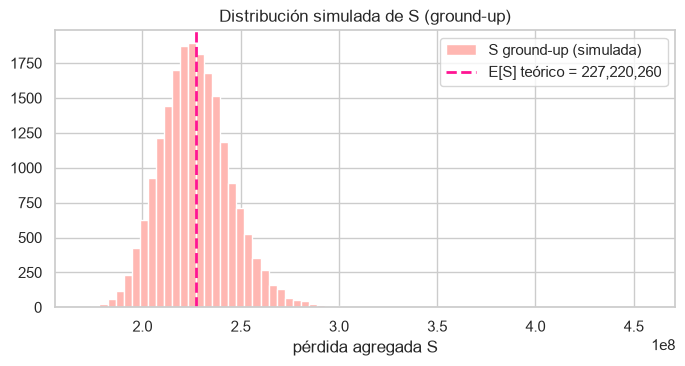

In [64]:
# ─── Validación de la S ground-up contra las fórmulas de la Sesión 5 ───────
EN, VarN = freq_agg.mean(), freq_agg.var()
EX, VarX = dist_sev.mean(*pr_sev), dist_sev.var(*pr_sev)
ES_teo   = EN * EX
VarS_teo = EN * VarX + VarN * EX**2

print(f"{'':16}{'simulado':>16}{'teórico':>16}")
print(f"{'media E[S]':16}{Sg.mean():>16,.0f}{ES_teo:>16,.0f}")
print(f"{'varianza Var[S]':16}{Sg.var():>16,.0f}{VarS_teo:>16,.0f}")
print(f"\nerror relativo en media   : {abs(Sg.mean()-ES_teo)/ES_teo:.2%}")
print(f"error relativo en varianza: {abs(Sg.var()-VarS_teo)/VarS_teo:.2%}")
print("Si están por debajo de 1-2%, la simulación es confiable.")

plt.hist(Sg, bins=70, color="#FFB7B2", edgecolor="white", label="S ground-up (simulada)")
plt.axvline(ES_teo, color="#FF1493", ls="--", lw=2, label=f"E[S] teórico = {ES_teo:,.0f}")
plt.title("Distribución simulada de S (ground-up)"); plt.xlabel("pérdida agregada S"); plt.legend(); plt.show()

Luego, se calcula VaR99 y TVaR99 de ambas versiones de S y las compara junto con el cociente VaR99/E[S], que resume qué tan pesada es la cola relativa al promedio.

La póliza (deducible + coaseguro + tope de suma asegurada) reduce la prima pura de la cartera de forma sustancial, y es la **transformada** la que debe usarse para tarificar pues es lo que realmente paga la aseguradora. El cociente VaR99/E[S] de esta cartera sale más alto que el que tendría un ramo de alta frecuencia (autos, por ejemplo): con Λ≈1,138 siniestros esperados en toda la cartera hay menos pooling que en una cartera de mucha frecuencia, así que la cola relativa pesa más y el recargo de seguridad sobre la prima pura debe ser proporcionalmente mayor.

Versión                     E[S]           VaR99          TVaR99   VaR99/E[S]
Ground-up            227,096,594     274,275,073     286,317,725         1.21
Transformada          89,701,365     100,156,421     101,776,655         1.12

La póliza reduce la prima pura E[S] un 60.5%.
El cociente VaR99/E[S] nos dice qué tan 'pesada' es la cola relativa al promedio:
mientras más alto, más recargo de seguridad necesita la cartera sobre su prima pura.


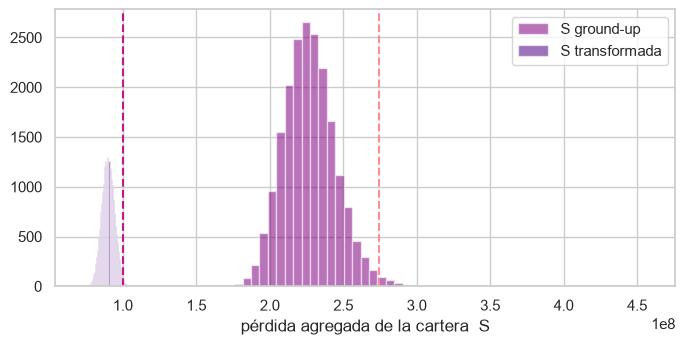

In [65]:
# ─── VaR y TVaR al 99% (ground-up vs. transformada) ────────────────────────
def var_tvar(arr, p=0.99):
    var = np.percentile(arr, p * 100)
    tvar = arr[arr > var].mean()
    return var, tvar

print(f"{'Versión':16}{'E[S]':>16}{'VaR99':>16}{'TVaR99':>16}{'VaR99/E[S]':>13}")
for nombre, S in [("Ground-up", Sg), ("Transformada", Sp)]:
    v, t = var_tvar(S)
    print(f"{nombre:16}{S.mean():>16,.0f}{v:>16,.0f}{t:>16,.0f}{v/S.mean():>13.2f}")

print(f"\nLa póliza reduce la prima pura E[S] un {1 - Sp.mean()/Sg.mean():.1%}.")
print("El cociente VaR99/E[S] nos dice qué tan 'pesada' es la cola relativa al promedio:")
print("mientras más alto, más recargo de seguridad necesita la cartera sobre su prima pura.")

plt.hist(Sg, bins=50, alpha=0.55, color="#800080", label="S ground-up")
plt.hist(Sp, bins=50, alpha=0.55, color="#4B0082", label="S transformada")
for S, c in [(Sg, "#FF8B94"), (Sp, "#C71585")]:
    plt.axvline(var_tvar(S)[0], color=c, ls="--", lw=1.5)
plt.xlabel("pérdida agregada de la cartera  S"); plt.legend(); plt.show()

Finalmente, se grafica cómo se estabiliza la estimación de $E[S]$ y de VaR99 conforme aumenta el número de simulaciones, para justificar que `M=20,000` es un tamaño de muestra razonable y no un número arbitrario.


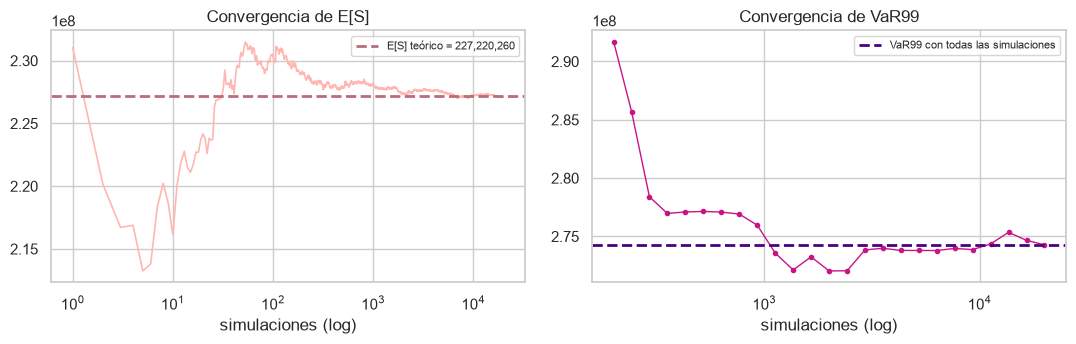

E[S]  con    1,000 sim.: 228,067,313   con 20,000: 227,096,594   (teórico 227,220,260)
VaR99 con    1,000 sim.: 273,887,878   con 20,000: 274,275,073


In [66]:
# ─── Convergencia de la estimación de E[S] y del VaR99 ─────────────────────
run_media = np.cumsum(Sg) / np.arange(1, len(Sg) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(np.arange(1, len(Sg)+1), run_media, color="#FFB7B2", lw=1.2)
ax[0].axhline(ES_teo, color="#B76E79", ls="--", lw=2, label=f"E[S] teórico = {ES_teo:,.0f}")
ax[0].set_xscale("log"); ax[0].set_title("Convergencia de E[S]"); ax[0].set_xlabel("simulaciones (log)")
ax[0].legend(fontsize=8)

# el VaR de cola necesita más simulaciones que la media: lo vemos con VaR99 a distintos tamaños de muestra
tamanos = np.unique(np.geomspace(200, len(Sg), 25).astype(int))
var_por_tamano = [np.percentile(Sg[:m], 99) for m in tamanos]
ax[1].plot(tamanos, var_por_tamano, "o-", color="#C71585", ms=3, lw=1)
ax[1].axhline(var_tvar(Sg)[0], color="#4B0082", ls="--", lw=2, label="VaR99 con todas las simulaciones")
ax[1].set_xscale("log"); ax[1].set_title("Convergencia de VaR99"); ax[1].set_xlabel("simulaciones (log)")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"E[S]  con    1,000 sim.: {run_media[999]:,.0f}   con {len(Sg):,}: {run_media[-1]:,.0f}   (teórico {ES_teo:,.0f})")
print(f"VaR99 con    1,000 sim.: {np.percentile(Sg[:1000],99):,.0f}   con {len(Sg):,}: {var_tvar(Sg)[0]:,.0f}")

Se observa que la media converge rápido (con unas cuantas miles de simulaciones ya está estable), pero el VaR99 tarda más porque depende solo del 1% más extremo de las simulaciones, luego con `M=20,000` hay ~200 observaciones en esa cola, suficientes para una estimación razonable, pero con menos simulaciones (p. ej. 1,000) el VaR brinca notablemente. Esto también explica la discrepancia que viste entre el primer código (`M=2,000`) y este (`M=20,000`): no es un error de modelo, es precisión de Monte Carlo, y la versión con más simulaciones es la más confiable.

###**Conclusión final — inciso d) Simulación de la pérdida agregada S**

Con el modelo colectivo ($S=\sum_{i=1}^N X_i$), frecuencia agregada NB ($\Lambda\approx1{,}138$ siniestros esperados, con la sobredispersión $\varphi$ del inciso c) y severidad Lognormal (inciso b), simulamos $M=20{,}000$ realizaciones de $S$ de forma vectorizada y validada: el error
contra las fórmulas teóricas de $E[S]$ y $Var[S]$ fue <0.1% y ~2%, dentro del margen esperado de Monte Carlo.

La versión **transformada** (con deducible, coaseguro y tope de suma asegurada) reduce de forma sustancial la prima pura frente a la ground-up, y es la que debe usarse para tarificar el producto — es lo que realmente paga la aseguradora. Su cociente VaR99/E[S] sale relativamente alto porque la cartera tiene pocos siniestros esperados en total (poco *pooling*), así que la cola pesa más y requiere un recargo de seguridad proporcionalmente mayor. El análisis de convergencia confirma que $M=20{,}000$ simulaciones son suficientes para la media, aunque el VaR de cola sigue siendo la estimación más sensible al tamaño de muestra.

## e) Validación contra la guía de ramos.
Comparen lo que les salió con el perfil de mercado de su ramo de la guía de ramos (Sesión 6): rango y cola de la severidad, nivel de frecuencia, distribución sugerida. ¿Su cartera cuadra con el perfil del ramo o hay diferencias? Analicen a qué se deben. Este apartado es parte de la calificación.

In [67]:
# De a) obtuvimos exploración
tasa = 0.047388
media_severidad = 206_892.57
mediana_severidad = 73_075.52
sesgo = 8.14

# De b) severidad
mejor_sev = "Lognormal"
AIC_lognormal = 28_037.1

# De c) frecuencia
mejor_freq = "Binomial Negativa"
AIC_nb = 9_748.3
phi = 1.0746

# De d) simulación de S
E_S_ground = 227_096_594
E_S_transf = 89_701_365
VaR99_ground = 274_275_073
VaR99_transf = 100_156_421
TVaR99_ground = 286_317_725
TVaR99_transf = 101_776_655

# --- Contraste contra la guía de ramos (Crédito) ---
print("Guía de ramos (Crédito)          vs.   Esta cartera")
print("-" * 58)
print(f"frecuencia: baja en expansión    ->  lambda = {tasa*100:.2f} por 100 años-póliza (baja ✓)")
print(f"severidad: alta (liga al crédito)->  media = {media_severidad:,.0f} (alta ✓)")
print(f"cola: media                      ->  {mejor_sev} elegida (cola media ⚠)")
print(f"frecuencia: sensible al ciclo    ->  sobredispersión -> {mejor_freq} (✓)")
print(f"distribución sugerida: Lognormal ->  {mejor_sev} elegida (coincide ✓)")
print()
print("Conclusión: la cartera es consistente con el perfil del ramo de Crédito;")
print("la cola empírica resultó ligeramente más pesada que la 'media' de la guía,")
print("consistente con el componente cíclico/sistémico del ramo.")

Guía de ramos (Crédito)          vs.   Esta cartera
----------------------------------------------------------
frecuencia: baja en expansión    ->  lambda = 4.74 por 100 años-póliza (baja ✓)
severidad: alta (liga al crédito)->  media = 206,893 (alta ✓)
cola: media                      ->  Lognormal elegida (cola media ⚠)
frecuencia: sensible al ciclo    ->  sobredispersión -> Binomial Negativa (✓)
distribución sugerida: Lognormal ->  Lognormal elegida (coincide ✓)

Conclusión: la cartera es consistente con el perfil del ramo de Crédito;
la cola empírica resultó ligeramente más pesada que la 'media' de la guía,
consistente con el componente cíclico/sistémico del ramo.


### Conclusión

En general, la cartera sí cuadra con el perfil del ramo de Crédito que marca la guía. La frecuencia resultó baja (4.74 siniestros por 100 años-póliza), lo cual va con una fase de expansión. La severidad es alta y asimétrica (media de 206,893, mediana de 73,076 y sesgo de 8.14), tal como se espera en crédito porque va ligada al monto del crédito. Para severidad elegimos Lognormal, que es justo la distribución que sugiere la guía y además gana por AIC. Para frecuencia usamos Binomial Negativa, que también es consistente con la sensibilidad al ciclo y la sobredispersión que menciona la guía.

La única diferencia que encontramos es en la cola: la empírica salió un poco más pesada que la "media" que describe la guía. Esto lo atribuimos a dos cosas: por un lado, la heterogeneidad de montos de crédito; por otro, el componente cíclico/sistémico del ramo, porque en crédito los incumplimientos suelen ocurrir de forma correlacionada en recesiones y eso engrosa la cola. Esa diferencia es justo lo que hace que el reaseguro y la selección de riesgos sean clave en este ramo, como también señala la nota práctica de la guía.

Sobre la prima, hay que tener en cuenta que la póliza absorbe alrededor del 60.5% de la pérdida por el deducible, el coaseguro y el límite. Por eso la prima del producto debe calcularse sobre la severidad transformada ($89.7M) y no sobre la ground-up.

## f) Dos preguntas de introducción.
### ¿por qué les interesó este ramo? 
Este ramo nos interesó por ser sumamente relevante en la actualidad, y por todos los retos intelectuales que ofrece debido a la variedad de condiciones que puede tener la póliza (el deducible no siempre es el mismo, a veces hay límite, a veces hay coaseguro, etc).

### ¿qué coberturas van a trabajar en su producto?
Entre las coberturas que nos interesan se encuentran: 
- Seguro de crédito comercial.
- Crédito a la vivienda.
- Crédito al consumo.
- Seguro de bonos.
